# Template Pengerjaan Tugas Supervised Learning

In [3]:
# data handling
import pandas as pd
import numpy as np

# visualisasi
import seaborn as sns
import matplotlib.pyplot as plt

# preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# models
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

# evaluasi
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## 1. Import Dataset dari Kaggle
- Akses situs Kaggle dan cari dataset yang relevan untuk tugas Supervised Learning.
- Unduh dataset menggunakan Kaggle API (jika tersedia) atau secara manual dengan mengklik tombol download pada halaman dataset.
- Simpan dataset ke dalam folder proyek dan pastikan format file sesuai (misalnya CSV atau ZIP yang perlu diekstrak).
- Load dataset ke dalam environment kerja menggunakan library yang sesuai, dan periksa struktur data awal seperti jumlah baris, kolom, dan tipe data.

In [4]:
data = pd.read_csv("diabetes.csv")
data = data.drop("Insulin", axis=1)

print(data.head())
print(data.info())

print("Shape:", data.shape)

   Pregnancies  Glucose  BloodPressure  SkinThickness   BMI  \
0            6      148             72             35  33.6   
1            1       85             66             29  26.6   
2            8      183             64              0  23.3   
3            1       89             66             23  28.1   
4            0      137             40             35  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             76

## 2. EDA (Exploratory Data Analysis)
- Lakukan analisis deskriptif untuk memahami distribusi data, termasuk statistik dasar seperti mean, median, mode, dan standar deviasi untuk setiap fitur.
- Visualisasikan data menggunakan plot seperti histogram, boxplot, scatter plot, atau heatmap korelasi untuk mengidentifikasi pola, outlier, dan hubungan antar variabel.
- Periksa missing values, duplikasi data, dan imbalance pada target variable jika ada.
- Identifikasi fitur-fitur penting yang mungkin mempengaruhi model berdasarkan analisis ini.

In [5]:
# statistik dasar
print(data.describe())

# mean
print("\nMean:\n", data.mean())

# median
print("\nMedian:\n", data.median())

# mode
print("\nMode:\n", data.mode().iloc[0])

# standar deviasi
print("\nStd Dev:\n", data.std())

print("\nJumlah Null:\n", data.isnull().sum())

print("\nJumlah Duplikat:\n", data.duplicated().sum())

       Pregnancies     Glucose  BloodPressure  SkinThickness         BMI  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   31.992578   
std       3.369578   31.972618      19.355807      15.952218    7.884160   
min       0.000000    0.000000       0.000000       0.000000    0.000000   
25%       1.000000   99.000000      62.000000       0.000000   27.300000   
50%       3.000000  117.000000      72.000000      23.000000   32.000000   
75%       6.000000  140.250000      80.000000      32.000000   36.600000   
max      17.000000  199.000000     122.000000      99.000000   67.100000   

       DiabetesPedigreeFunction         Age     Outcome  
count                768.000000  768.000000  768.000000  
mean                   0.471876   33.240885    0.348958  
std                    0.331329   11.760232    0.476951  
min                    0.078000   21.000000    0.000000  
25%                    0.

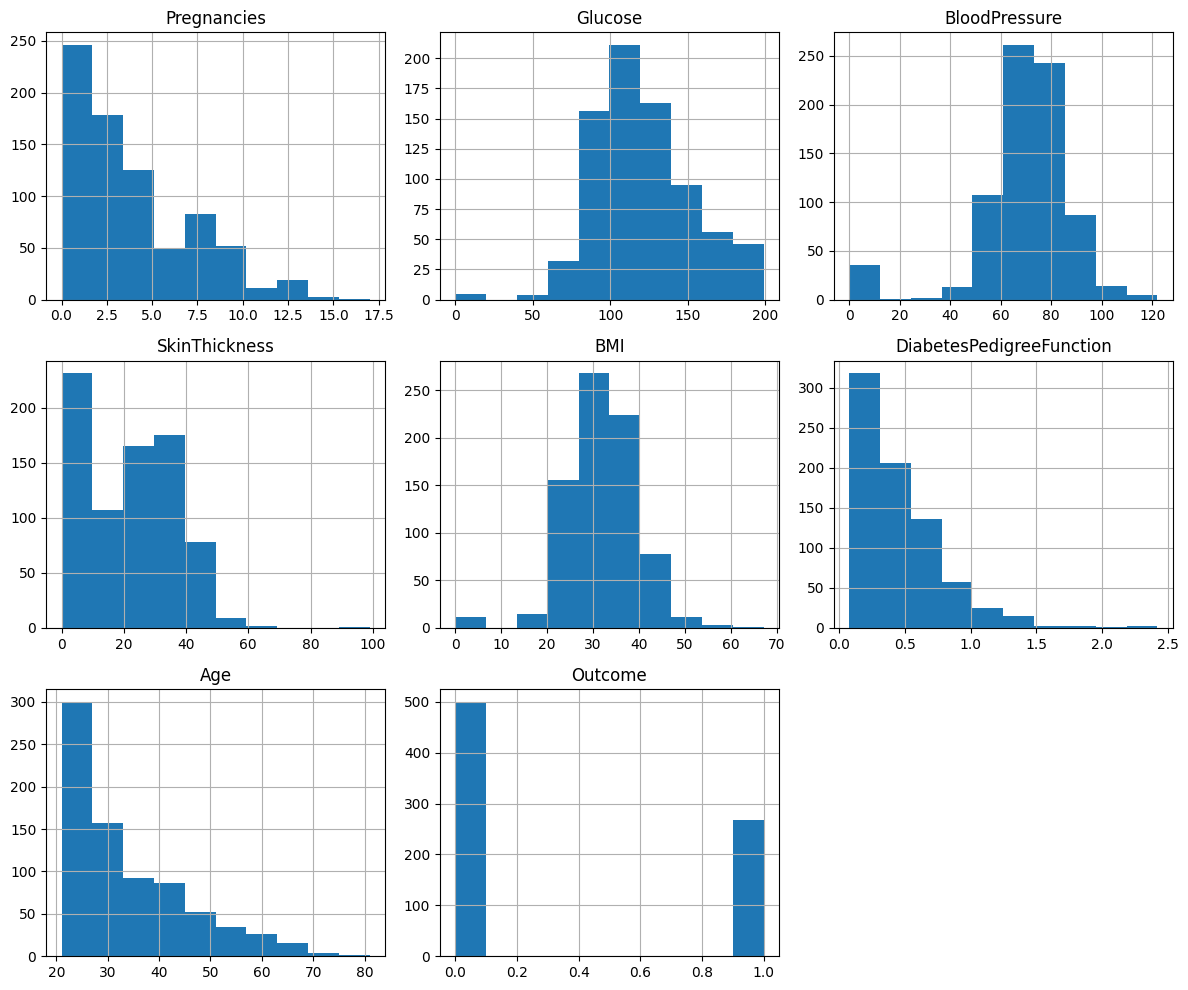

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

data.hist(figsize=(12,10))
plt.tight_layout()
plt.show()

In [7]:
# plt.figure(figsize=(12,8))
# sns.kdeplot(data=data, x='Insulin')
# plt.show()

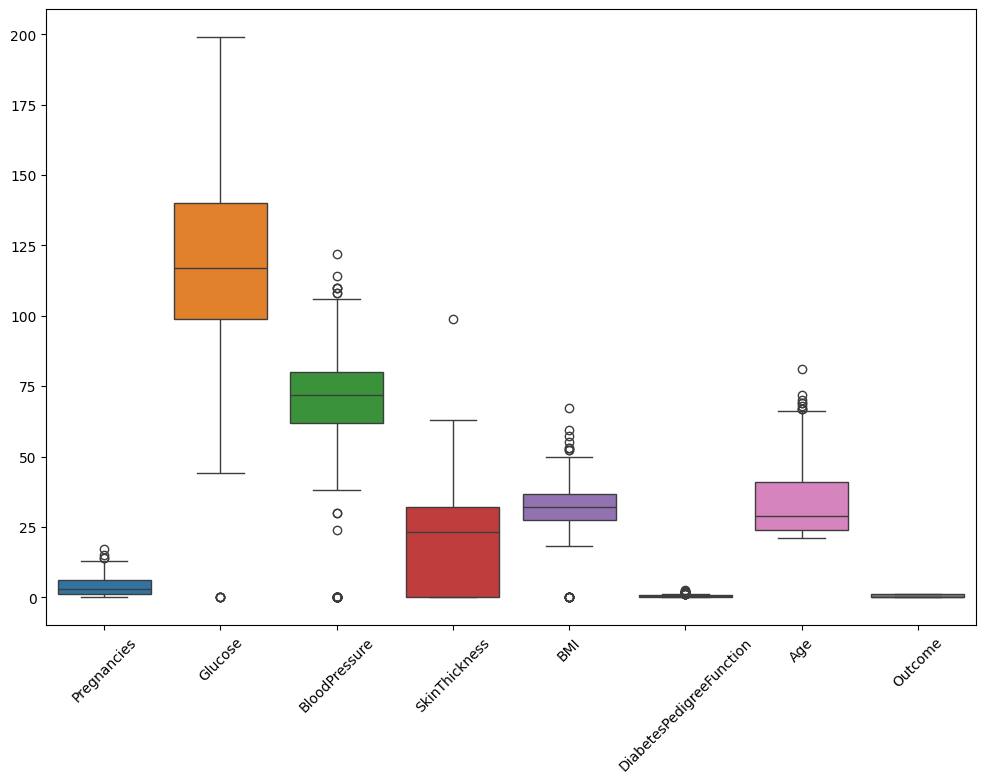

In [8]:
plt.figure(figsize=(12,8))
sns.boxplot(data=data)
plt.xticks(rotation=45)
plt.show()

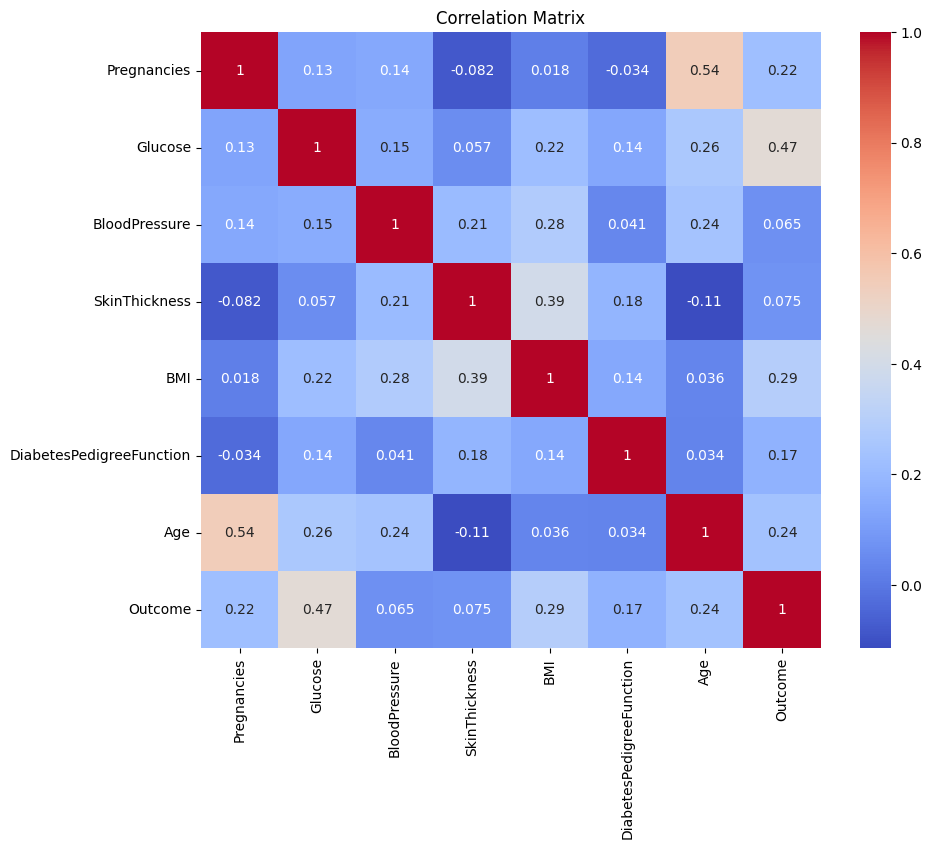

In [9]:
plt.figure(figsize=(10,8))
sns.heatmap(data.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [10]:
# sns.scatterplot(x="Age", y="Pregnancies", hue="Outcome", data=data)
# plt.show()

# sns.scatterplot(x="SkinThickness", y="Insulin", hue="Outcome", data=data)
# plt.show()

# sns.scatterplot(x="SkinThickness", y="BMI", hue="Outcome", data=data)
# plt.show()

# sns.scatterplot(x="Insuline", y="Glucose", hue="Outcome", data=data)
# plt.show()

In [11]:
# missing value
print(data.isnull().sum())

# cek nilai 0
cols = ["Glucose", "BloodPressure", "SkinThickness", "BMI"]

for col in cols:
    print(f"{col} zero count:", (data[col] == 0).sum())

print("Duplicate rows:", data.duplicated().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64
Glucose zero count: 5
BloodPressure zero count: 35
SkinThickness zero count: 227
BMI zero count: 11
Duplicate rows: 0


Outcome
0    500
1    268
Name: count, dtype: int64


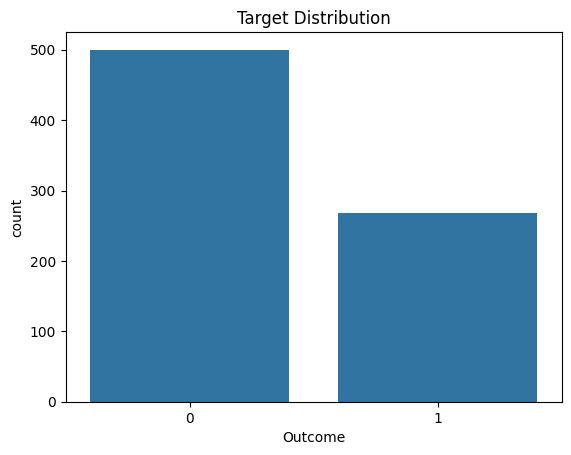

In [ ]:
# print(data["Outcome"].value_counts())

# sns.countplot(x="Outcome", data=data)
# plt.title("Target Distribution")
# plt.show()

         Pregnancies     Glucose  BloodPressure  SkinThickness        BMI  \
Outcome                                                                     
0           3.298000  109.980000      68.184000      19.664000  30.304200   
1           4.865672  141.257463      70.824627      22.164179  35.142537   

         DiabetesPedigreeFunction        Age  
Outcome                                       
0                        0.429734  31.190000  
1                        0.550500  37.067164  


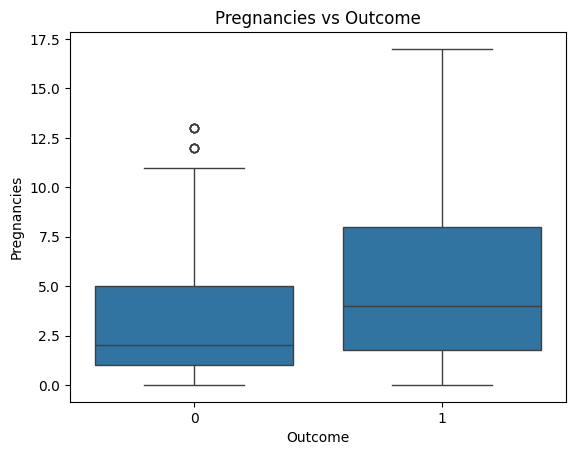

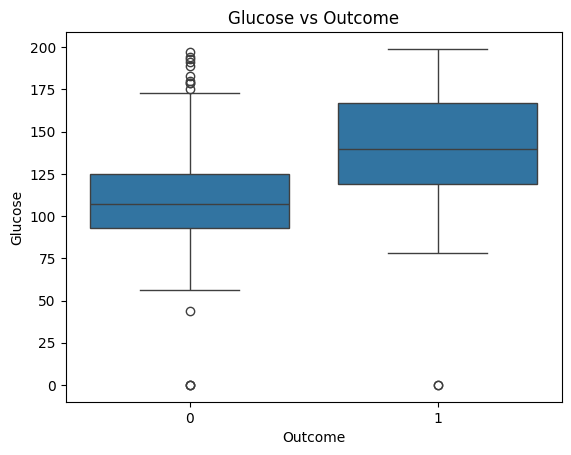

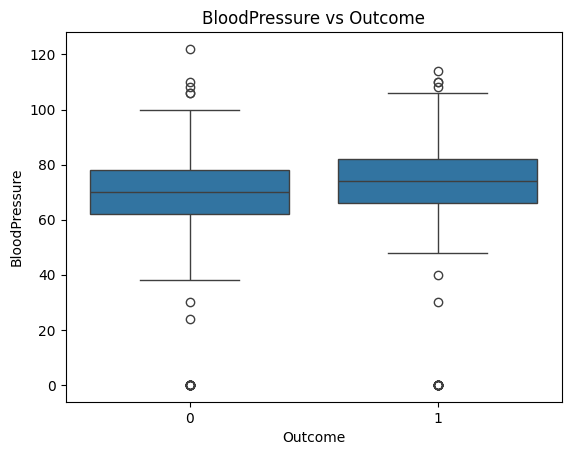

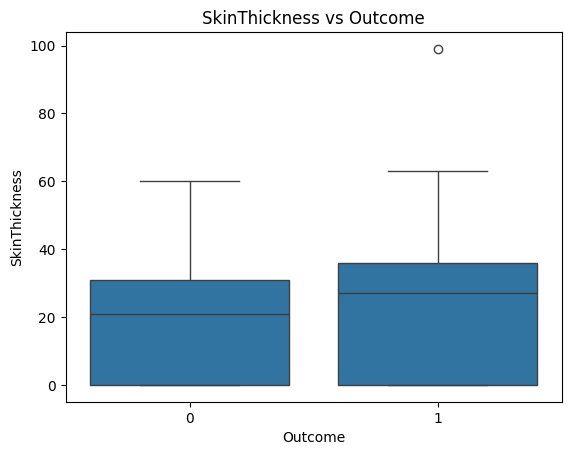

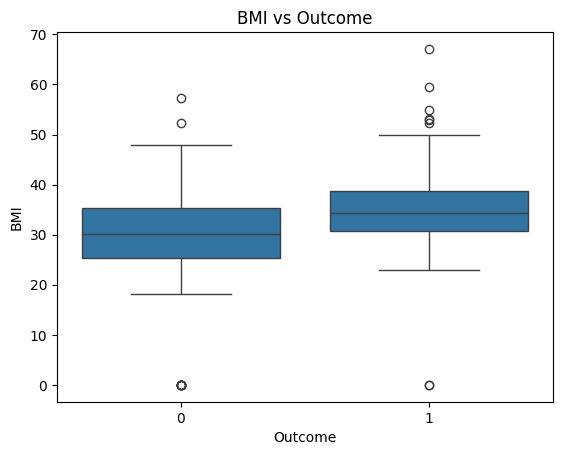

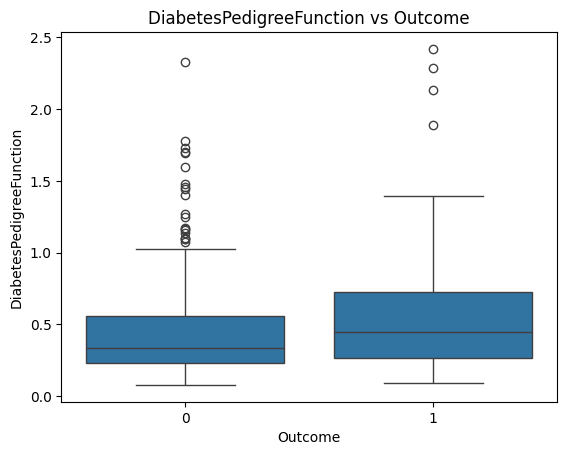

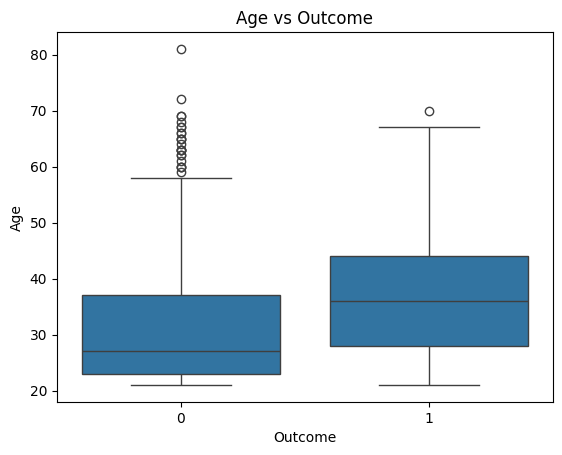

In [13]:
# rata-rata tiap fitur berdasarkan Outcome
print(data.groupby("Outcome").mean())

features = data.columns[:-1]

for col in features:
    sns.boxplot(x="Outcome", y=col, data=data)
    plt.title(f"{col} vs Outcome")
    plt.show()

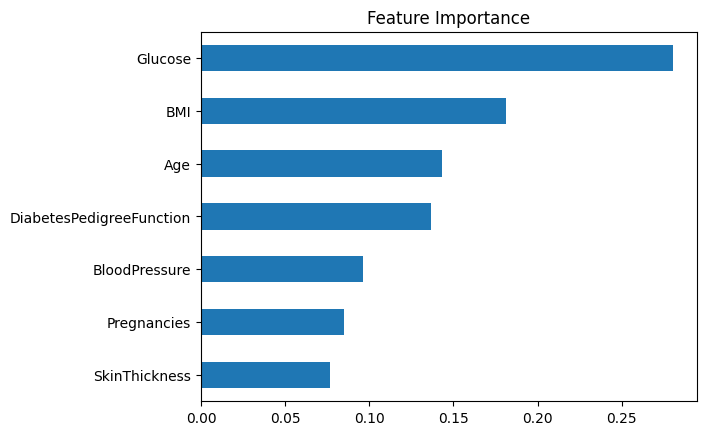

In [14]:
from sklearn.ensemble import RandomForestClassifier

X = data.drop("Outcome", axis=1)
y = data["Outcome"]

model = RandomForestClassifier()
model.fit(X, y)

importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values().plot(kind="barh")
plt.title("Feature Importance")
plt.show()

## 3. Preprocessing
- Tangani missing values dengan metode seperti imputasi (mean/median untuk numerik, mode untuk kategorikal) atau penghapusan baris/kolom jika diperlukan.
- Lakukan encoding untuk variabel kategorikal, misalnya menggunakan one-hot encoding atau label encoding.
- Normalisasi atau standarisasi fitur numerik untuk memastikan skala yang seragam, terutama jika menggunakan model berbasis jarak seperti KNN.
- Pisahkan dataset menjadi fitur (X) dan target (y), serta bagi menjadi data training dan testing (misalnya 80:20).
- Jika diperlukan, lakukan feature selection atau engineering untuk meningkatkan performa model.

In [15]:
import numpy as np

cols = ["Glucose", "BloodPressure", "SkinThickness", "BMI"]

data[cols] = data[cols].replace(0, np.nan)

In [16]:
for col in cols:
    data[col].fillna(data[col].median(), inplace=True)

/tmp/ipykernel_15693/1366271820.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[col].fillna(data[col].median(), inplace=True)


In [17]:
data["Glucose_BMI"] = data["Glucose"] * data["BMI"]
data["Age_BMI"] = data["Age"] * data["BMI"]


In [18]:
data.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0
Glucose_BMI,0
Age_BMI,0


In [19]:
X = data.drop("Outcome", axis=1)
y = data["Outcome"]

# split dulu
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# fit hanya di train
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# test hanya transform
X_test_scaled = scaler.transform(X_test)

## 4. Modelling
- Pilih dan implementasikan tiga model Supervised Learning: Decision Tree, Naive Bayes, dan KNN.
- Untuk Decision Tree: Gunakan algoritma pohon keputusan untuk klasifikasi atau regresi, atur parameter dasar seperti max_depth.
- Untuk Naive Bayes: Terapkan model probabilitas berbasis teorema Bayes, cocok untuk data kategorikal atau numerik dengan asumsi independensi fitur.
- Untuk KNN (K-Nearest Neighbors): Gunakan algoritma berbasis jarak, tentukan nilai K (jumlah tetangga) yang optimal.
- Latih masing-masing model menggunakan data training dan pastikan model dapat memprediksi data testing.

In [20]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

In [21]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
nb.fit(X_train_scaled, y_train)

y_pred_nb = nb.predict(X_test_scaled)

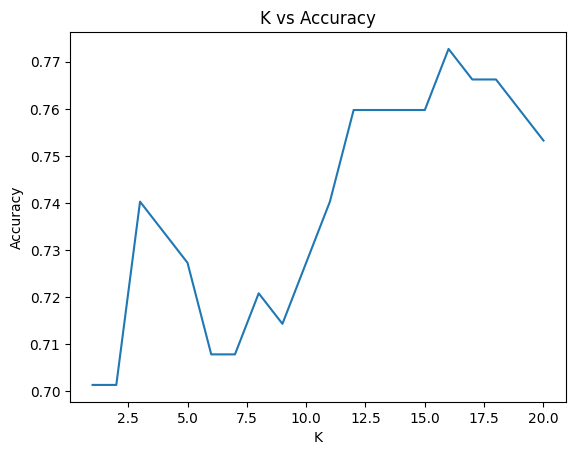

In [22]:
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt

k_values = range(1, 21)
scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    scores.append(knn.score(X_test_scaled, y_test))

plt.plot(k_values, scores)
plt.xlabel("K")
plt.ylabel("Accuracy")
plt.title("K vs Accuracy")
plt.show()

In [23]:
knn = KNeighborsClassifier(n_neighbors=8)
knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

In [24]:
from sklearn.metrics import accuracy_score, classification_report

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))

Decision Tree Accuracy: 0.6688311688311688
Naive Bayes Accuracy: 0.7077922077922078
KNN Accuracy: 0.7207792207792207


## 5. Eksperiment
- Lakukan Cross-Validation untuk mengevaluasi stabilitas model, misalnya menggunakan 5-fold atau 10-fold CV pada data training.
- Terapkan K-Fold Cross-Validation secara eksplisit untuk membagi data menjadi K subset dan hitung rata-rata performa.
- Lakukan Hyperparameter Tuning untuk setiap model, seperti mencari nilai optimal untuk max_depth di Decision Tree, K di KNN, atau parameter smoothing di Naive Bayes, menggunakan teknik seperti Grid Search atau Random Search.
- Bandingkan hasil eksperiment untuk menentukan konfigurasi terbaik bagi masing-masing model.

In [25]:
from sklearn.model_selection import cross_val_score

cv_dt = cross_val_score(dt, X_train, y_train, cv=5)
cv_nb = cross_val_score(nb, X_train_scaled, y_train, cv=5)
cv_knn = cross_val_score(knn, X_train_scaled, y_train, cv=5)

print("DT CV:", cv_dt.mean())
print("NB CV:", cv_nb.mean())
print("KNN CV:", cv_knn.mean())

DT CV: 0.7410902305744369
NB CV: 0.7573237371717979
KNN CV: 0.7443555910968945


In [26]:
from sklearn.model_selection import KFold
import numpy as np

kf = KFold(n_splits=5, shuffle=True, random_state=42)

scores = []

for train_idx, val_idx in kf.split(X_train):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    dt.fit(X_tr, y_tr)
    scores.append(dt.score(X_val, y_val))

print("Manual K-Fold DT:", np.mean(scores))

Manual K-Fold DT: 0.7166200186592029


In [27]:
from sklearn.model_selection import GridSearchCV

param_dt = {
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10],
    "criterion": ["gini", "entropy"]
}

grid_dt = GridSearchCV(DecisionTreeClassifier(), param_dt, cv=5)
grid_dt.fit(X_train, y_train)

print("Best DT:", grid_dt.best_params_)

Best DT: {'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 5, 'min_samples_split': 2}


In [28]:
param_knn = {
    "n_neighbors": range(1, 31),   # lebih luas
    "weights": ["uniform", "distance"],
    "p": [1, 2]  # Manhattan vs Euclidean
}

grid_knn = GridSearchCV(KNeighborsClassifier(), param_knn, cv=5)
grid_knn.fit(X_train_scaled, y_train)

print("Best KNN:", grid_knn.best_params_)

Best KNN: {'n_neighbors': 16, 'p': 2, 'weights': 'distance'}


In [29]:
param_nb = {
    "var_smoothing": np.logspace(-12, -6, 20)
}
grid_nb = GridSearchCV(GaussianNB(), param_nb, cv=5)
grid_nb.fit(X_train_scaled, y_train)

print("Best NB:", grid_nb.best_params_)

Best NB: {'var_smoothing': np.float64(1e-12)}


In [30]:
from sklearn.model_selection import RandomizedSearchCV

random_knn = RandomizedSearchCV(
    KNeighborsClassifier(),
    param_knn,
    n_iter=20,
    cv=5,
    random_state=42
)

random_knn.fit(X_train_scaled, y_train)

RandomizedSearchCV(cv=5, estimator=KNeighborsClassifier(), n_iter=20,
                   param_distributions={'n_neighbors': range(1, 31),
                                        'p': [1, 2],
                                        'weights': ['uniform', 'distance']},
                   random_state=42)

In [31]:
best_dt = grid_dt.best_estimator_
best_knn = grid_knn.best_estimator_
best_nb = grid_nb.best_estimator_

print("DT tuned:", best_dt.score(X_test, y_test))
print("KNN tuned:", best_knn.score(X_test_scaled, y_test))
print("NB tuned:", best_nb.score(X_test_scaled, y_test))

DT tuned: 0.7337662337662337
KNN tuned: 0.7792207792207793
NB tuned: 0.7077922077922078


## 6. Evaluasi
- Evaluasi performa model menggunakan metrik: Confusion Matrix (untuk melihat true positive, false positive, dll.), F1-Score (untuk balance antara precision dan recall), dan Akurasi (persentase prediksi benar).
- Hitung metrik ini untuk setiap model pada data testing, dan bandingkan hasilnya.
- Analisis hasil evaluasi untuk mengidentifikasi kekuatan dan kelemahan masing-masing model, seperti overfitting atau underfitting.

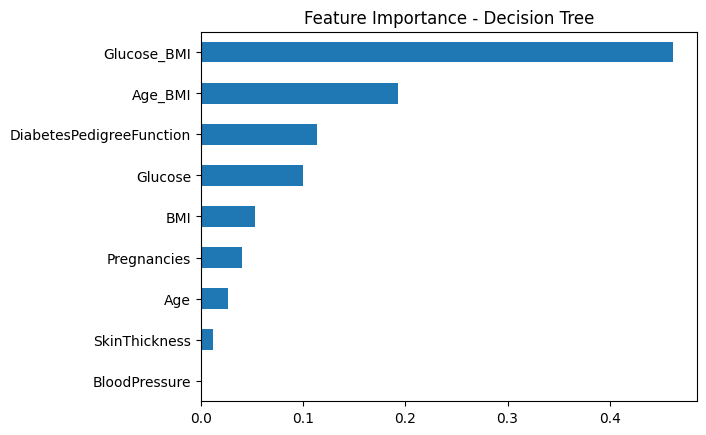

In [32]:
import pandas as pd
import matplotlib.pyplot as plt

importance_dt = pd.Series(dt.feature_importances_, index=X.columns)

importance_dt.sort_values().plot(kind="barh")
plt.title("Feature Importance - Decision Tree")
plt.show()

In [35]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

models = {
    "Decision Tree": best_dt,
    "Naive Bayes": best_nb,
    "KNN": best_knn
}

for name, model in models.items():
    if name == "Decision Tree":
        y_pred = model.predict(X_test)
    else:
        y_pred = model.predict(X_test_scaled)

    print(f"{name} :")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))


=== Decision Tree ===
Accuracy: 0.7337662337662337
Confusion Matrix:
 [[91  9]
 [32 22]]
Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.91      0.82       100
           1       0.71      0.41      0.52        54

    accuracy                           0.73       154
   macro avg       0.72      0.66      0.67       154
weighted avg       0.73      0.73      0.71       154


=== Naive Bayes ===
Accuracy: 0.7077922077922078
Confusion Matrix:
 [[76 24]
 [21 33]]
Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.76      0.77       100
           1       0.58      0.61      0.59        54

    accuracy                           0.71       154
   macro avg       0.68      0.69      0.68       154
weighted avg       0.71      0.71      0.71       154


=== KNN ===
Accuracy: 0.7792207792207793
Confusion Matrix:
 [[90 10]
 [24 30]]
Classification Report:
               pr

## 7. Rangkuman

Pada tugas ini dilakukan pembangunan model *Supervised Learning* untuk memprediksi diabetes berdasarkan dataset medis. Proses yang dilakukan meliputi tahap Exploratory Data Analysis (EDA), preprocessing, modeling, eksperimen, hingga evaluasi model.

### 1. Exploratory Data Analysis (EDA)
Berdasarkan hasil eksplorasi data, ditemukan beberapa nilai tidak logis berupa angka 0 pada fitur seperti *Glucose, BloodPressure, SkinThickness,* dan *BMI*. Nilai tersebut diperlakukan sebagai *missing values*. Selain itu, fitur seperti *Glucose, BMI,* dan *Age* menunjukkan hubungan yang cukup kuat terhadap variabel target (*Outcome*). Distribusi target relatif seimbang meskipun terdapat sedikit ketimpangan.

### 2. Preprocessing
Pada tahap preprocessing dilakukan beberapa langkah penting:
- Mengganti nilai 0 dengan *NaN* lalu melakukan imputasi menggunakan median.
- Menghapus fitur *Insulin* karena memiliki banyak noise dan kurang informatif.
- Menambahkan fitur baru (*feature engineering*) seperti:
  - `Glucose_BMI`
  - `Age_BMI`
- Melakukan normalisasi menggunakan *StandardScaler* untuk model berbasis jarak seperti KNN dan Naive Bayes.

### 3. Modeling
Tiga model yang digunakan dalam tugas ini adalah:
- Decision Tree
- Naive Bayes
- K-Nearest Neighbors (KNN)

Hasil awal menunjukkan bahwa KNN memiliki akurasi tertinggi, sedangkan Decision Tree memiliki performa paling rendah.

### 4. Eksperimen
Eksperimen dilakukan dengan beberapa metode:
- *Cross Validation (5-Fold)* untuk mengukur stabilitas model
- Implementasi *manual K-Fold* untuk memahami mekanisme pembagian data
- *Hyperparameter tuning* menggunakan GridSearch dan RandomizedSearch

Hasil menunjukkan bahwa:
- Naive Bayes memiliki performa paling stabil berdasarkan cross-validation
- KNN tetap memberikan hasil terbaik pada data testing
- Hyperparameter tuning tidak selalu meningkatkan performa secara signifikan

### 5. Evaluasi Model
Evaluasi dilakukan menggunakan metrik:
- Accuracy
- Confusion Matrix
- Precision, Recall, dan F1-Score

Hasil evaluasi menunjukkan:
- KNN memiliki akurasi tertinggi namun sensitif terhadap distribusi data
- Naive Bayes lebih stabil dan memiliki generalisasi yang baik
- Decision Tree cenderung mengalami underfitting

Dalam konteks medis, metrik *recall* untuk kelas diabetes (1) menjadi sangat penting karena kesalahan *False Negative* harus diminimalkan.

### 6. Feature Importance
Analisis feature importance menunjukkan bahwa fitur yang paling berpengaruh sebelum masuk ke proses feature engineering adalah:
- Glucose
- BMI
- Age

Hal ini sesuai dengan pengetahuan medis bahwa faktor metabolik memiliki peran penting dalam risiko diabetes.

### 7. Kesimpulan
Pemilihan model terbaik tidak hanya berdasarkan akurasi, tetapi juga mempertimbangkan stabilitas dan kemampuan generalisasi. KNN cocok digunakan jika fokus pada akurasi tertinggi, sedangkan Naive Bayes lebih unggul dalam hal konsistensi performa.

Selain itu, *feature engineering* terbukti lebih efektif dalam meningkatkan performa model dibandingkan hanya melakukan tuning parameter.

### 8. Insight
Dari tugas ini dapat dipelajari bahwa:
- Preprocessing dan feature engineering sangat berpengaruh terhadap performa model
- Cross-validation memberikan evaluasi yang lebih stabil dibandingkan satu kali pengujian
- Pemilihan model harus disesuaikan dengan konteks permasalahan
- Dalam kasus medis, interpretasi hasil model sama pentingnya dengan nilai akurasi